
 Recorded Time: 2.049238681793213


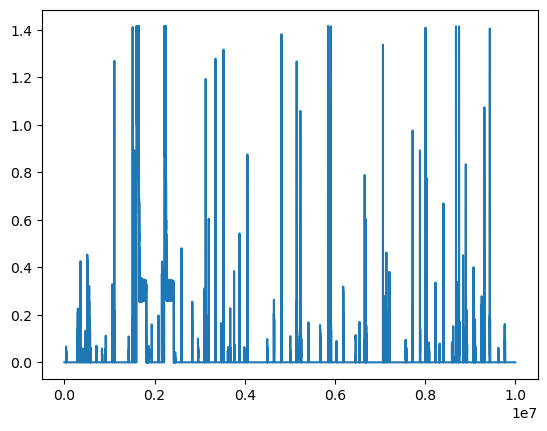


number of frames: 2
# Frame OK ...

file size is: 3468456
Size OK .
Testing receive rate at FREQ: 2.420 GHz and RX_RATE: 5 Msps on 1 channels.

Done!


In [257]:
import uhd, os, time
import numpy as np
import matplotlib.pyplot as plt
import yaml

import sys


import dataProcessing 
utills = dataProcessing.Utills()


#load the configuration file
with open("config.yaml", 'r') as stream:
    try:
        config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

TX_RATE = config['TX_RATE']
FREQ = config['FREQ']
GAIN = config['GAIN']
TX_SPS = config['SPS']
PREAMBLE = config['PREAMBLE']
PAYLOAD = config['PAYLOAD']





RX_RATE = 5e6 
LINIENT = 3
mimo = False
file_name = "test"
acq_time = 2 # in second

FFT_SIZE = int(TX_SPS * RX_RATE/TX_RATE)
Freq_deviation_precentage = 5/100 

gain = "agc"

# THRESHOLD = 0

inChamber = False


# Santizing Check param the recorded file size and number of frames
minSize = 1e3
maxSize = 99.99e6
minFrames = 2
maxFrames = 40

minFrameSize = 1000* TX_SPS * RX_RATE/TX_RATE





if mimo: 
    chnls = [0,1]
else:
    chnls = [0]

# save the configuration
config['RX_RATE'] = RX_RATE
config['LINIENT'] = LINIENT
config['mimo'] = mimo
config['file_name'] = file_name
config['acq_time'] = acq_time
config['FFT_SIZE'] = FFT_SIZE
config['Freq_deviation_precentage'] = Freq_deviation_precentage
config['inChamber'] = inChamber
config['minSize'] = minSize
config['maxSize'] = maxSize
config['minFrames'] = minFrames
config['maxFrames'] = maxFrames
config['minFrameSize'] = minFrameSize



args = "serial=8000182"
usrp = uhd.usrp.MultiUSRP(args=args)
# uhd.usrp.SubdevSpec("0:A  1:D")



# this might change later due to wrong FREQ or RX_RATE selection and actual value will be replaced
file = file_name + "_"+str(np.round(FREQ,2))+"_"+str(np.round(RX_RATE,2))+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_.iq"

def _config_streamer(usrp,chnls,spp = None):
    st_args = uhd.usrp.StreamArgs("fc32", "sc16")
    st_args.channels = chnls
    # st_args.args = "spp="+str(spp)
    streamer = usrp.get_rx_stream(st_args)

    return streamer

def _batch_init(streamer,batch_size = None):
    if batch_size is None:
        batch_size = streamer.get_max_num_samps()
    nr_batches= int(acq_time * RX_RATE / batch_size)
    return batch_size, nr_batches

def _start_stream(streamer,batch_size):
    stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.start_cont)
    stream_cmd.num_samps = batch_size
    stream_cmd.stream_now = False  
    stream_cmd.time_spec = uhd.types.TimeSpec(usrp.get_time_now().get_real_secs() + 0.05)   
    streamer.issue_stream_cmd(stream_cmd)

def _stop_stream(streamer,recv_buffer):
    metadata = uhd.types.RXMetadata()
    stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.stop_cont)
    streamer.issue_stream_cmd(stream_cmd)
    while streamer.recv(recv_buffer, metadata):
        pass



# %%

def record(Linient = 30):
    usrp.set_time_now(uhd.types.TimeSpec(0.0)) # this should work well for syncing the MIMO channel

    streamer = _config_streamer(usrp=usrp, chnls=chnls,spp=None)
    batch_size, nr_batches = _batch_init(streamer=  streamer, batch_size= None)
    recv_buffer = np.zeros((len(chnls), batch_size), dtype=np.complex64)
    metadata = uhd.types.RXMetadata()

    for chnl in chnls:
        usrp.set_rx_rate(RX_RATE, chnl)
        usrp.set_rx_freq(uhd.libpyuhd.types.tune_request(FREQ), chnl)
        # usrp.set_rx_gain(gain, chnl)

    usrp.set_rx_agc(True, 0)

    _start_stream(streamer = streamer,batch_size= batch_size)

    #updating file name if mimo
    if mimo:
        file1 = file_name + "_"+str(np.round(usrp.get_rx_freq(),2))+"_"+str(np.round(usrp.get_rx_rate(),2))+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_1.iq"
        file2 = file_name + "_"+str(np.round(usrp.get_rx_freq(),2))+"_"+str(np.round(usrp.get_rx_rate(),2))+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_2.iq"
        f1 = open(file1,"wb")
        f2 = open(file2,"wb")

        start = time.time()
        for i in range(nr_batches):
            streamer.recv(recv_buffer, metadata)
            # np.zeros(1).tofile(f)
            recv_buffer[0].tofile(f1)
            recv_buffer[1].tofile(f2)
        duration = time.time() - start
        print("\n Recorded Time: " + str(duration))
        # Stop Stream
        _stop_stream(streamer=streamer, recv_buffer=recv_buffer)
        f1.close()
        f2.close()
        return streamer, file1, file2

    else:
        file = file_name + "_"+str(np.round(usrp.get_rx_freq(),2))+"_"+str(np.round(usrp.get_rx_rate(),2))+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_.iq"
        f = open(file,"wb")

        start = time.time()
        cnt = 4
        for i in range(nr_batches):
            streamer.recv(recv_buffer, metadata)
            fft = np.abs(np.fft.fft(recv_buffer[0]))
            if np.sum(
                np.concatenate(
                            [
                            fft[1:int(Freq_deviation_precentage*len(fft))], 
                            fft[int(1-Freq_deviation_precentage*batch_size):]
                            ]
                        )
                    ) > 1.4*2*Freq_deviation_precentage*np.sum(fft[int(Freq_deviation_precentage*batch_size): int(1-Freq_deviation_precentage*batch_size)]):
                recv_buffer[0].tofile(f) 
                cnt = 0   
            else:
                recv_buffer[0].tofile(f) if (cnt:=cnt+1) < Linient else np.zeros(batch_size, dtype=np.complex64).tofile(f)
            

        duration = time.time() - start
        print("\n Recorded Time: " + str(duration))
        # Stop Stream
        _stop_stream(streamer=streamer, recv_buffer=recv_buffer)
        f.close()
        return streamer, file


streamer, files = record(Linient=LINIENT)

# PyQtGraph setup


# %%


# %%

samples = None
def file_santizer(file, minSize = 30e6,maxSize = 1e9,minFrames = 100,maxFrames = 1000, minFrameSize = 1): 
    global samples
    
    samples = np.fromfile(file, np.complex64) # Read in file.  We have to tell it what format it is
    plt.plot(np.abs(samples))
    plt.show()  

    framesIndex = utills.frameFinder(samples, minFrameSize=minFrameSize)
    utills.zeroRemover(file = file, samples=samples,framesIndex=framesIndex)     

    #check minimum number of the frames
    nr_frame = len(framesIndex)
    print("\nnumber of frames: " + str(nr_frame))
    if  nr_frame < minFrames or  nr_frame > maxFrames:
        print("# Frame check failed ...")
    else:
        print("# Frame OK ...")


    # Check the file size
    size = os.path.getsize(file)
    print("\nfile size is: " + str(os.path.getsize(file)))
    if size < minSize or size > maxSize:
        print("Size check failed ...    ")
    else:
        print("Size OK .")




### tests

if mimo:
    file_santizer(file=files[0],minSize = minSize,maxSize = maxSize,minFrames = minFrames,maxFrames = maxFrames, minFrameSize= minFrameSize)
    file_santizer(file=files[1],minSize = minSize,maxSize = maxSize,minFrames = minFrames,maxFrames = maxFrames, minFrameSize= minFrameSize)
else:
    file_santizer(file=files,minSize = minSize,maxSize = maxSize,minFrames = minFrames,maxFrames = maxFrames, minFrameSize= minFrameSize)

print("Testing receive rate at FREQ: {:.3f} GHz and RX_RATE: {:.0f} Msps on {:d} channels.".format(
    usrp.get_rx_freq()/1e9, usrp.get_rx_rate()/1e6, streamer.get_num_channels()))
print("\nDone!")


File name has a correct format!


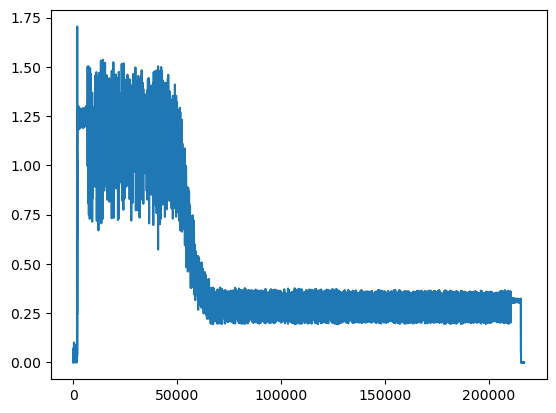

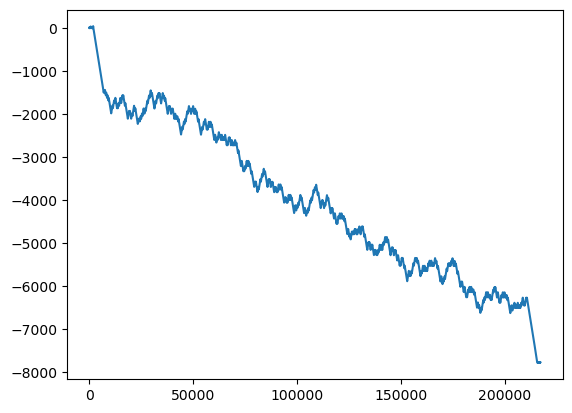

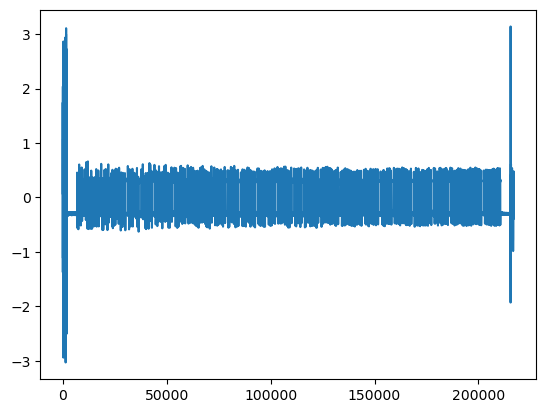

In [258]:
import dataProcessing 
import matplotlib.pyplot as plt
import scipy.signal

utills = dataProcessing.Utills()
IQdata, tindx = utills.readFile(file=file)

def butter(input, cutoff, Fs):
    fltr = scipy.signal.butter(10, cutoff, 'low', analog=False, output='sos',fs=Fs)
    return scipy.signal.sosfilt(fltr, input) 



# utills.plotter(IQdata = IQdata, tindx = tindx, batch= 4, frameShowLimit=-1, compression_ratio= 1, fft=1)
# plt.plot(np.abs(IQdata.frameByNumber(1)))
plt.show()
frame= IQdata.frameByNumber(0)
# frame = frame * np.exp(2j*np.pi*np.linspace(0,len(frame),len(frame))/len(frame))
filtered_frame = butter(frame, 5e5, RX_RATE)
plt.plot(np.abs(filtered_frame))
plt.show()




unwrapped = IQdata.unwrapPhase(IQdata.phase(filtered_frame))
plt.plot(unwrapped)
plt.show()

diff = np.diff(unwrapped)
plt.plot(diff)
plt.show()



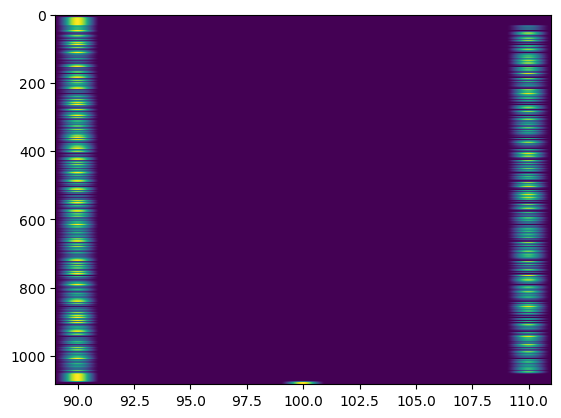

Max Peak: 182 Min Peak: 63


In [259]:

# compute sliding fft of the signal every 40 samples where the peak is 1 and the rest 0
window = FFT_SIZE
slide = FFT_SIZE
frame2 = frame.copy()
frame2 = frame2[24:]
def fft_max_peak(frame,window,slide):
    fft = np.fft.fftshift(np.fft.fft(frame[:window]))
    peak = np.argmax(np.abs(fft))
    fft[peak] = 1
    fft[fft!=1] = 0
    return fft, peak

def decision(peak, threshold):
    return 0 if peak < threshold else 1

res= []
fft,peak = fft_max_peak(frame2,window,slide)
maxPeak = peak
minPeak = peak
res.append(decision(peak = peak, threshold=window//2))
for i in range(slide,len(frame2)-window,slide):
    fft2, peak  = fft_max_peak(frame2[i:i+window],window,slide)
    if peak > maxPeak:
        maxPeak = peak
    if peak < minPeak:
        minPeak = peak
    res.append(decision(peak=peak, threshold=window//2))
    fft = np.vstack((fft,fft2))
plt.imshow(np.abs(fft),aspect='auto')
plt.xlim(FFT_SIZE//2-Freq_deviation_precentage*FFT_SIZE - 1,FFT_SIZE//2+Freq_deviation_precentage*FFT_SIZE  + 1)
plt.show()

print("Max Peak: " + str(maxPeak), "Min Peak: " + str(minPeak)) 

In [260]:
def find_subarray(data, sub):
    """
    Return the starting index of the first occurrence of sub in data,
    or -1 if sub is not found.
    """
    n, m = len(data), len(sub)
    if m == 0:
        return 0  # Edge case: empty subarray
    for i in range(n - m + 1):
        if data[i:i+m] == sub:
            return i
    return -1

def get_frame(data, preamble, postamble, include_markers=False):
    # 1. Find the first occurrence of the preamble.
    start_idx = find_subarray(data, preamble)
    if start_idx == -1:
        return None  # Preamble not found

    # 2. Find the first occurrence of the postamble, starting after preamble ends.
    end_search_start = start_idx + len(preamble)
    end_idx = find_subarray(data[end_search_start:], postamble)
    if end_idx == -1:
        return None  # Postamble not found

    # Adjust end_idx relative to the original data
    end_idx += end_search_start

    if include_markers:
        # Return from start of preamble to end of postamble
        return data[start_idx : end_idx + len(postamble)]
    else:
        # Return only what's between the preamble and postamble
        return data[start_idx + len(preamble) : end_idx]
    
def bits_to_string(bit_list):
    """
    Convert list/array of bits to ASCII string (8-bit, MSB first).
    """
    chars = []
    for i in range(0, len(bit_list), 8):
        byte_bits = bit_list[i:i+8]
        if len(byte_bits) < 8:
            break
        val = 0
        for b in byte_bits:
            val = (val << 1) | b
        chars.append(chr(val))
    return "".join(chars)



In [261]:
preamble = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1] 
postamble = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
frame_only = get_frame(res, preamble, postamble, include_markers=False)

bits_to_string(frame_only), len(frame_only)

('I want to know why the world was created and how this is so cool to have built things that you never could have done/have seen.',
 1016)

In [262]:
from scipy.sparse import coo_matrix
import ldpc.code_util

def load_base_matrix_from_text(filename):
    """
    Loads a base matrix from a text file.
    Each line corresponds to a row of integers.
    Returns a 2D NumPy array with shape (R, C).
    """
    rows = []
    
    with open(filename, 'r') as f:
        for line in f:
            # Strip whitespace, split by spaces
            str_vals = line.strip().split()
            # Convert each token to an int
            int_vals = list(map(int, str_vals))
            rows.append(int_vals)
    
    # Convert list of lists into a NumPy array
    # This assumes all rows have the same length
    base_matrix = np.array(rows, dtype=int)
    
    return base_matrix

def expand_submatrix(shift, Z):
    """
    Given a shift value and a lifting factor Z,
    return the Z x Z submatrix (in sparse format) that represents
    a cyclic shift (if shift >= 0) or a zero matrix (if shift == -1).
    """
    if shift == -1:
        # No connection => Zero submatrix
        data = []
        row = []
        col = []
        return coo_matrix((data, (row, col)), shape=(Z, Z))

    # For a shift >= 0, create a ZxZ identity matrix shifted by 'shift' columns (mod Z).
    # The (i, i+shift mod Z) = 1 for i in [0..Z-1].
    data = np.ones(Z, dtype=int)
    row = np.arange(Z)
    col = (row + shift) % Z
    return coo_matrix((data, (row, col)), shape=(Z, Z))

def create_5g_nr_parity_check_matrix(base_graph='BG1', Z=4):
    """
    Construct a 5G NR-like parity-check matrix H for demonstration.
    base_graph: 'BG1' or 'BG2'
    Z: lifting factor (must be a positive integer, typically up to 384)
    
    Returns: A scipy.sparse.coo_matrix representing the parity-check matrix.
    """
    # ------------------------------------------------
    # 1) Define a *partial* base graph from 3GPP 38.212 
    #    to keep it short. In reality, you need the full matrix.
    # 
    #    -1 means no edge
    #    0..(Z-1) means a shifted identity submatrix
    #
    #    BG1 is 46 x 68 in real 5G, BG2 is 42 x 52.
    # ------------------------------------------------
    
    if base_graph == 'BG1':
        # Partial BG1 example (4 rows x 6 cols)
        # Real BG1 is 46 x 68. This is just an example subset:
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_1_0_128.txt')
    else:
        # Partial BG2 example (again, not the full matrix)
        # Real BG2 is 42 x 52. 
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_2_0_128.txt')
    
    R, C = base_graph_matrix.shape
    
    # ------------------------------------------------
    # 2) Expand the base graph
    # ------------------------------------------------
    big_data = []
    big_row = []
    big_col = []
    
    for r in range(R):
        for c in range(C):
            sub_H = expand_submatrix(base_graph_matrix[r, c], Z)
            
            # The top-left corner of the submatrix in the full H
            row_offset = r * Z
            col_offset = c * Z
            
            # Convert sub_H into COO to extract data, row, col
            sub_H_coo = sub_H.tocoo()
            
            # Append to global row/col/data
            big_data.extend(sub_H_coo.data)
            big_row.extend(sub_H_coo.row + row_offset)
            big_col.extend(sub_H_coo.col + col_offset)
    
    # Final matrix size is (R*Z) x (C*Z)
    H = coo_matrix((big_data, (big_row, big_col)), shape=(R*Z, C*Z), dtype=int)
    
    return H


